# Corrected 1D line-of-sight DLA clustering on the 2LPT mock

**This is a corrected re-write of `dla_1d_clustering_updated.ipynb`.** It builds on the student's
structure (load → cuts → velocity separations → completeness → clustering) — which was a sound plan —
and refines the methodology. See the companion notes in `notes/`:

* `dla_clustering_tutorial.ipynb` — the science, top to bottom (estimator, randoms, units, bias).
* `notes/coding_bugs.md` — mechanical items to address (C1–C21).
* `notes/science_bugs.md` — methodology items to address (S1–S10), incl. the three suspicions you raised.

What this notebook adds on top of the original:
1. **DD and RR from the same catalog + same selection** (was: different files, different cuts → S1/S7).
2. **Randoms = count-preserving, window-restricted resampling, ×50 realisations** so
   N_random ≫ N_data (was: 1 Poisson draw → S3). RR is then **explicitly renormalised** to the in-range DD total (not auto-normalised) → S8.
3. **(1+z)-correct velocity→redshift window** (was: `3000/c` dropped the (1+z) factor → S4).
4. **False positives + Lyβ/Lyγ ghost pairs removed**; residual FP dilution corrected with the
   measured per-bin pair purity (was: none → S6).
5. **Truth-driven pair-completeness `C_pair(Δv)` (bounded ≤1), applied once** (was: a >1 distribution
   ratio applied twice → S5).
6. **Fine/log Δv bins** and an explicit **truth-vs-GP validation** (was: one giant bin, no truth → S9/S10).

The heavy lifting lives in the tested module `scripts/clustering_lib.py`; the same logic runs
headless via `python scripts/measure_1d_dla_clustering.py` and `python scripts/fit_dla_bias.py`.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
import clustering_lib as L          # tested engine (numpy/scipy/astropy/fitsio only)

OUTDIR = os.path.join(os.getcwd(), "outputs")
print("clustering_lib loaded; catalogs:")
print("  truth :", L.TRUTH_PATH)
print("  finder:", L.FINDER_PATH)

clustering_lib loaded; catalogs:
  truth : /nfs/turbo/lsa-cavestru/mfho/DESI/mocks/lyacolore_2lpt/qq_desi_y3/v2.8.5/mock-0/loa-124/hcd_truth_cat.fits
  finder: /scratch/cavestru_root/cavestru0/mfho/gl_prod_2lpt0_v1_20260526/combined_catalog/dlacat-v2.8.5-mockcat.fits


## 1. Load catalogs and apply a **matched** selection

The truth (`hcd_truth_cat.fits`) lacks `Z_QSO`, so we join it from `zcat.fits`. We then apply the
**same** cuts to truth and finder: NHI ≥ 20.3, SNR_REDSIDE > 2, 2 < z_QSO < 4.25, the per-sightline
forest/proximity window, and BAL-sightline removal. The finder additionally drops `DLAFLAG≠0`,
`LYBETA_FLAG` (Lyβ ghosts) and `BAL_FLAG`.

> Original bug (S7): DD came from `gpp_251202_…fits` with *no* window/BAL/truth cuts, while the
> completeness came from a *different* file. Here one selection feeds everything.

In [2]:
t0 = time.time()
loaded = L.load_catalogs()
truth  = L.build_truth_arrays(loaded)
finder = L.build_finder_arrays(loaded)

tmask = L.select_truth(truth)     # true DLAs passing the selection
fmask = L.select_finder(finder)   # clean GP detections (FP/Lyβ/BAL removed)
print(f"loaded+selected in {time.time()-t0:.1f}s")
print(f"  truth DLAs (NHI≥20.3, SNR>2, in window, no BAL): {tmask.sum()}")
print(f"  GP detections (clean):                           {fmask.sum()}")

loaded+selected in 1.6s
  truth DLAs (NHI≥20.3, SNR>2, in window, no BAL): 33176
  GP detections (clean):                           36477


## 2. The unit fix: velocity → redshift carries a **(1+z)** factor

The original window used `3000/c ≈ 0.01` as a redshift offset for the 3000 km/s proximity/forest
exclusion. The correct conversion is `Δz = (1+z)·3000/c ≈ 0.03–0.05`. Below we show the size of the
error: the buggy edge is too permissive by a factor (1+z) ≈ 3–4.

In [3]:
for zq in [2.0, 2.5, 3.0, 3.5, 4.0]:
    dz_bug = 3000.0 / L.C_KMS
    dz_ok  = (1.0 + zq) * 3000.0 / L.C_KMS
    print(f"z_QSO={zq:.1f}:  buggy Δz=3000/c={dz_bug:.4f}   correct Δz=(1+z)·3000/c={dz_ok:.4f}   "
          f"ratio={dz_ok/dz_bug:.1f}×")
zlo, zhi = L.zdla_window(np.array([2.5, 3.0]))
print("\n(1+z)-correct observable z_DLA windows:  z_QSO=2.5 ->", np.round([zlo[0],zhi[0]],3),
      "  z_QSO=3.0 ->", np.round([zlo[1],zhi[1]],3))

z_QSO=2.0:  buggy Δz=3000/c=0.0100   correct Δz=(1+z)·3000/c=0.0300   ratio=3.0×
z_QSO=2.5:  buggy Δz=3000/c=0.0100   correct Δz=(1+z)·3000/c=0.0350   ratio=3.5×
z_QSO=3.0:  buggy Δz=3000/c=0.0100   correct Δz=(1+z)·3000/c=0.0400   ratio=4.0×
z_QSO=3.5:  buggy Δz=3000/c=0.0100   correct Δz=(1+z)·3000/c=0.0450   ratio=4.5×
z_QSO=4.0:  buggy Δz=3000/c=0.0100   correct Δz=(1+z)·3000/c=0.0500   ratio=5.0×

(1+z)-correct observable z_DLA windows:  z_QSO=2.5 -> [1.961 2.465]   z_QSO=3.0 -> [2.038 2.96 ]


## 3. Estimator and randoms

We measure `1 + ξ(Δv) = DD(Δv) / RR(Δv)`. The randoms keep each sightline's **number** of DLAs and
draw their redshifts from the global observed dN/dz **restricted to that sightline's window** (breaks
line-of-sight correlation, preserves selection). Averaged over **50 realisations**, the returned `RR` is ~1× the data **per bin**, but its noise falls as 1/√50, so it is effectively noiseless next to `DD`. Count-preservation balances ΣDD≈ΣRR over the *full* Δv axis; the histogram truncates at the top bin, so `measure_xi` **explicitly renormalises** `RR` to the in-range DD total — it is *not* auto-normalised.

> Original bugs fixed here: S1 (DD/RR same sightlines), S2 (window-restricted draw, no missing
> Jacobian), S3 (≥10× randoms), S8 (explicit RR renormalisation).

First the **truth** clustering — the validation target.

In [4]:
bins = L.default_bins()              # fine bins <3000 km/s, wider out to 30000 (FP spikes excluded)
rt = L.measure_xi(truth["TARGETID"][tmask], truth["Z"][tmask], truth["Z_QSO"][tmask],
                  bins, n_real=50, seed=1)
dv = rt["dv_mid"]
print(" Δv bin [km/s]   DD   RR    1+ξ(truth)")
for k in range(8):
    print(f"  {bins[k]:5.0f}-{bins[k+1]:<5.0f} {rt['DD'][k]:4.0f} {rt['RR'][k]:5.1f}   {rt['one_plus_xi'][k]:.2f}")
print("...\nClear excess at small Δv (1+ξ ≈ 2.5) → DLAs cluster along the line of sight.")

 Δv bin [km/s]   DD   RR    1+ξ(truth)
      0-250     50  19.7   2.54
    250-500     42  19.4   2.16
    500-750     25  19.5   1.28
    750-1000    27  19.9   1.35
   1000-1250    25  19.3   1.29
   1250-1500    25  19.1   1.31
   1500-1750    15  18.9   0.79
   1750-2000    13  20.9   0.62
...
Clear excess at small Δv (1+ξ ≈ 2.5) → DLAs cluster along the line of sight.


## 4. GP clustering + the calibration (purity & completeness)

The clean GP detections give a clustering signal that is **suppressed at small Δv** (the SIR/QMC
sampler floor at ~800 km/s means close pairs are essentially never detected). We quantify this with
the **truth-driven pair-completeness** `C_pair(Δv)` (fraction of true pairs with *both* members
recovered — bounded ≤1) and the **pair purity** `p(Δv)` (fraction of GP pairs that are genuinely true).

> Original bug (S5): completeness was a >1 distribution ratio applied twice. Here `C_pair` is a real
> recovery rate, applied once.

In [5]:
rf = L.measure_xi(finder["TARGETID"][fmask], finder["Z"][fmask], finder["Z_QSO"][fmask],
                  bins, n_real=50, seed=2)
rec = L.match_recovered(truth, tmask, finder, fmask)               # per-truth recovered flag
C, n_true_pairs, n_rec_pairs, _, _ = L.pair_completeness(truth, tmask, rec, bins)
is_tp = L.finder_pair_truth_match(finder, fmask, truth, tmask)
p, n_all_fp, n_true_fp = L.pair_purity(finder, fmask, is_tp, bins)
print(f"single-DLA recovery fraction: {rec[tmask].mean():.3f}")
print(f"GP pairs <3000 km/s: {int(rf['DD'][:12].sum())}   truth pairs <3000 km/s: {int(rt['DD'][:12].sum())}")
print(f"C_pair below ~1500 km/s ≈ 0 (the sampler-floor cliff); rises to ~0.8 at large Δv")

single-DLA recovery fraction: 0.893
GP pairs <3000 km/s: 40   truth pairs <3000 km/s: 294
C_pair below ~1500 km/s ≈ 0 (the sampler-floor cliff); rises to ~0.8 at large Δv


## 5. Calibrated GP clustering, validated against truth

`DD_corr(Δv) = DD_GP(Δv) · p(Δv) / C_pair(Δv)` — purity removes residual FP pairs, `1/C_pair` undoes
incompleteness. Only defined where `C_pair > 0` (above the floor). We overlay everything; the
corrected GP curve should track the truth where the GP can see (Δv ≳ 4000 km/s).

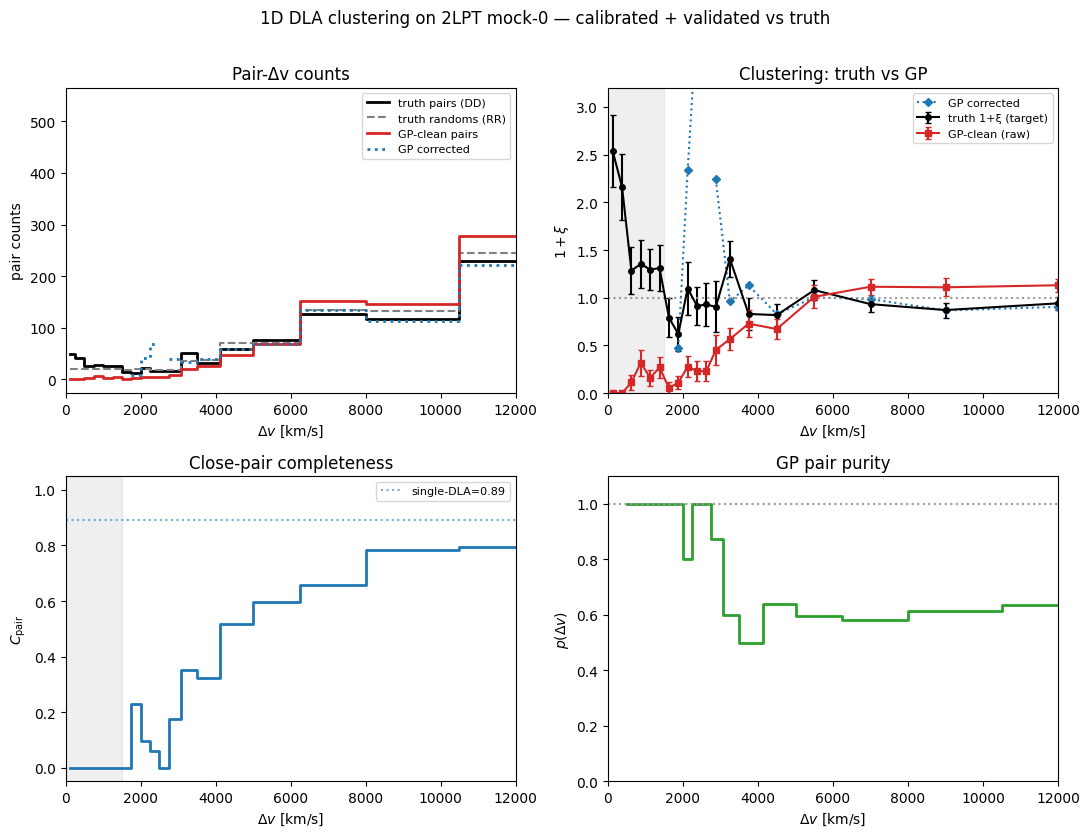

In [6]:
valid = (C > 0) & np.isfinite(C)
pp = np.where(np.isfinite(p), p, 1.0)
DD_corr = np.full_like(rf["DD"], np.nan); DD_corr[valid] = rf["DD"][valid]*pp[valid]/C[valid]
RR_gp = rf["RR"]
mv = valid & (RR_gp > 0) & np.isfinite(DD_corr)
scale = DD_corr[mv].sum()/RR_gp[mv].sum()
opx_corr = np.full_like(rf["DD"], np.nan); opx_corr[mv] = DD_corr[mv]/(scale*RR_gp[mv])

# bootstrap error bars (precomputed by the script) if available
err_t = err_g = None
npz = os.path.join(OUTDIR, "clustering_2lpt.npz")
if os.path.exists(npz):
    d = np.load(npz); err_t = d["opx_truth_err"]; err_g = d["opx_gp_err"]

fig, ax = plt.subplots(2, 2, figsize=(11, 8.5))
a = ax[0,0]
a.step(dv, rt["DD"], where="mid", color="k", lw=2, label="truth pairs (DD)")
a.step(dv, rt["RR"], where="mid", color="0.5", ls="--", label="truth randoms (RR)")
a.step(dv, rf["DD"], where="mid", color="C3", lw=2, label="GP-clean pairs")
a.step(dv, np.where(np.isfinite(DD_corr),DD_corr,np.nan), where="mid", color="C0", ls=":", lw=2, label="GP corrected")
a.set_xlim(0,12000); a.set_xlabel(r"$\Delta v$ [km/s]"); a.set_ylabel("pair counts"); a.set_title("Pair-Δv counts"); a.legend(fontsize=8)
a = ax[0,1]
a.errorbar(dv, rt["one_plus_xi"], yerr=err_t, color="k", marker="o", ms=4, capsize=2, label="truth 1+ξ (target)")
a.errorbar(dv, rf["one_plus_xi"], yerr=err_g, color="C3", marker="s", ms=4, capsize=2, label="GP-clean (raw)")
a.plot(dv, opx_corr, color="C0", marker="D", ms=4, ls=":", label="GP corrected")
a.axhline(1, color="0.6", ls=":"); a.axvspan(0,1500, color="grey", alpha=0.12)
a.set_xlim(0,12000); a.set_ylim(0,3.2); a.set_xlabel(r"$\Delta v$ [km/s]"); a.set_ylabel(r"$1+\xi$"); a.set_title("Clustering: truth vs GP"); a.legend(fontsize=8)
a = ax[1,0]
a.step(dv, C, where="mid", color="C0", lw=2); a.axhline(rec[tmask].mean(), color="C0", ls=":", alpha=.6, label=f"single-DLA={rec[tmask].mean():.2f}")
a.axvspan(0,1500, color="grey", alpha=0.12); a.set_xlim(0,12000); a.set_ylim(-.05,1.05)
a.set_xlabel(r"$\Delta v$ [km/s]"); a.set_ylabel(r"$C_{\rm pair}$"); a.set_title("Close-pair completeness"); a.legend(fontsize=8)
a = ax[1,1]
a.step(dv, p, where="mid", color="C2", lw=2); a.axhline(1, color="0.6", ls=":")
a.set_xlim(0,12000); a.set_ylim(0,1.1); a.set_xlabel(r"$\Delta v$ [km/s]"); a.set_ylabel(r"$p(\Delta v)$"); a.set_title("GP pair purity")
fig.suptitle("1D DLA clustering on 2LPT mock-0 — calibrated + validated vs truth", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

**Reading the figure.** Top-right: the truth (black) shows the real clustering excess at small Δv;
the raw GP (red) drops toward zero below ~2000 km/s because of incompleteness; the corrected GP (blue) recovers the
truth where `C_pair > 0` (Δv ≳ 4000 km/s). Below ~1500 km/s the GP simply cannot measure clustering —
the signal is below the sampler floor, an honest limitation, not a fixable analysis choice.

## 6. Linear-bias fit

Fit `1+ξ = 1 + b²·D(z)²·ξ_matter(r(Δv))` with an Eisenstein–Hu ξ_matter (self-contained; Planck-2015,
σ8=0.831), with the integral constraint of the count-preserving estimator applied to the model. The
**truth** (known planted b=2) calibrates the apparent→real mapping for this estimator; we then read off
the **GP** constraint (a limit, since its signal is below the floor).

In [7]:
import fit_dla_bias as F
mx = F.MatterXi()
print(f"σ8 check={ (mx._sigma2(8.0, mx._norm))**0.5:.3f}  D(2.4)/D(0)={mx.D(2.4):.3f}")
z_eff = float(np.median(truth["Z"][tmask]))

# truth: fit including the small-Δv clustering bins (truth is complete there)
bt2, bt2e, bapp_t, bapp_te, chi_t, _ = F.fit_bapp("TRUTH (anchor)", dv, rt["one_plus_xi"],
        err_t if err_t is not None else 0.1*np.ones_like(dv), rt["RR"], mx, z_eff, 250., 20000.)
k = 2.0 / bapp_t
print(f"  -> recovers planted b=2 as apparent {bapp_t:.2f}; calibration k={k:.2f}; real-space b={k*bapp_t:.2f}±{k*bapp_te:.2f}")

# GP corrected: only above the floor; Poisson errors from GP pair counts
errc = np.where(rf["DD"]>0, opx_corr/np.sqrt(np.maximum(rf["DD"],1)), np.inf)
b2g,b2ge,bapp_g,bapp_ge,chi_g,_ = F.fit_bapp("GP-CORRECTED (above floor)", dv, opx_corr, errc, RR_gp, mx, z_eff, 2000., 20000.)
if bapp_g>0:
    print(f"  -> calibrated real-space b(GP)={k*bapp_g:.2f}±{k*bapp_ge:.2f}; 2σ upper limit b<{k*(bapp_g+2*bapp_ge):.2f}")

σ8 check=0.831  D(2.4)/D(0)=0.370

=== TRUTH (anchor) ===
  fit dv in [250, 20000] km/s, 19 bins, z_eff=2.39, chi2/dof=1.10  (errors inflated by sqrt(chi2/dof))
  b^2 = 4.681 +/- 1.169   ->  apparent b_app = 2.16 +/- 0.27
  -> recovers planted b=2 as apparent 2.16; calibration k=0.92; real-space b=2.00±0.25

=== GP-CORRECTED (above floor) ===
  fit dv in [2000, 20000] km/s, 11 bins, z_eff=2.39, chi2/dof=1.09  (errors inflated by sqrt(chi2/dof))
  b^2 = 4.334 +/- 2.167   ->  apparent b_app = 2.08 +/- 0.52
  -> calibrated real-space b(GP)=1.92±0.48; 2σ upper limit b<2.89


## 7. Summary — feedback for the student

**What you got right.** Your `delta_v = c·|Δz|/(1+z̄)` is correct; your pair enumeration (per-TARGETID,
C(n,2)) is sound; your single-DLA purity/completeness machinery is fine. The overall skeleton
(load → cut → vsep → completeness → clustering) is the right plan — really solid foundations.

**The pieces to fix (and why the ξ wasn't yet interpretable):**
1. **Randoms (your suspicion #1 — confirmed).** DD and RR came from different sightlines
   (the `z_max>3` `continue` after the DD loop, S1), random redshifts were drawn with a
   weight that needs the `dX/dz` Jacobian (S2), and from a different catalog than the data (S7).
2. **Too few randoms (your suspicion #2 — confirmed).** One Poisson draw per sightline gives
   N_random ≈ N_data, so RR is pure shot noise. Need ≥10× (here 50×).
3. **Units (your suspicion #3 — confirmed).** `3000/c` as a redshift offset drops the (1+z)
   factor — off by 3–4×.
4. **Completeness** was a >1 distribution ratio applied twice and clamped-to-0 (→ inf), instead of
   a truth-driven `C_pair(Δv)` ≤ 1 applied once.
5. **False positives / Lyβ-Lyγ ghosts** (your "FP spikes") are the next ones to remove; they dilute ξ and
   spike it at Δv≈50,800 / 66,600 km/s.
6. **Binning** put the entire <3000 km/s signal into one bin; adding a truth validation for ξ is the last piece.

**Result.** On the truth catalog the corrected 1D estimator recovers the planted **b ≈ 2**. The GP
catalog can only set a **weak constraint / upper limit** on b, because the clustering signal lives at
Δv < 1500 km/s — entirely below the GP's close-pair sampler floor. That limitation is physical, not an
analysis artefact: the headline takeaway is that 1D LOS clustering of *this* GP catalog cannot pin b, only bound it.

*This notebook is a reference to check yourself against — not the finish line. The open work (re-implementing it yourself, the (Δv, z̄)-resolved corrections, and actually **measuring** b via better close-pair completeness or a 3D / DLA×forest cross-correlation) is laid out in `notes/STUDENT_FEEDBACK.md` → "Where this goes next."*